# Handwritten Digit Classification using CNN (PyTorch + MNIST)

## Introduction

In this project, we build a Convolutional Neural Network (CNN) to classify handwritten digits from the MNIST dataset.

The goal is to develop a simple yet effective deep learning model while understanding the fundamentals of:
- Image classification
- Convolutional Neural Networks (CNNs)
- Model training and evaluation in PyTorch

This notebook is designed to be **clear, reproducible, and beginner-friendly**, making it a solid starting point for anyone entering the field of Deep Learning.

## Problem Statement

The objective of this project is to build a supervised machine learning model capable of correctly classifying handwritten digits (0–9).

Given:
- A grayscale image of size 28x28 pixels

The model must predict:
- The corresponding digit label (0 to 9)

This is a **multi-class classification problem** with 10 possible output classes.

**Evaluation Metric:**
- Accuracy

## Dataset Description

The MNIST dataset is one of the most widely used datasets in computer vision and deep learning.

**Key characteristics:**
- Total samples: 70,000 images
  - Training set: 60,000
  - Test set: 10,000
- Image size: 28x28 pixels
- Color: Grayscale (1 channel)
- Classes: 10 (digits from 0 to 9)

**Source:**
- Yann LeCun et al.
- Available via `torchvision.datasets.MNIST`

**Preprocessing steps:**
- Conversion to tensors
- Normalization (mean = 0.5, std = 0.5)

## Importing Libraries

In [1]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import seaborn as sns

In [2]:
# =========================================================
# 2. REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [3]:
# =========================================================
# 3. DEVICE CONFIGURATION
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Data Loading and Preprocessing

In [4]:
# =========================================================
# 4. DATA LOADING AND PREPROCESSING
# =========================================================
class MNISTDataset(Dataset):
    def __init__(self, images_path, labels_path):
        with open(labels_path, "rb") as lbpath:
            self.labels = np.frombuffer(lbpath.read(), dtype=np.uint8, offset=8)

        with open(images_path, "rb") as imgpath:
            self.images = np.frombuffer(imgpath.read(), dtype=np.uint8, offset=16)
            self.images = self.images.reshape(len(self.labels), 28, 28)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx].astype(np.float32) / 255.0
        image = torch.tensor(image).unsqueeze(0)  # Shape: [1, 28, 28]
        label = int(self.labels[idx])
        return image, label

# Dataset path
base_path = "/kaggle/input/datasets/hojjatk/mnist-dataset"

# Load training dataset
train_dataset = MNISTDataset(
    os.path.join(base_path, "train-images.idx3-ubyte"),
    os.path.join(base_path, "train-labels.idx1-ubyte")
)

# Load test dataset
test_dataset = MNISTDataset(
    os.path.join(base_path, "t10k-images.idx3-ubyte"),
    os.path.join(base_path, "t10k-labels.idx1-ubyte")
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Display dataset information
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training samples: 60000
Test samples: 10000
Training batches: 938
Test batches: 157


## Data Exploration

Before training the model, let's visualize some sample images from the dataset.

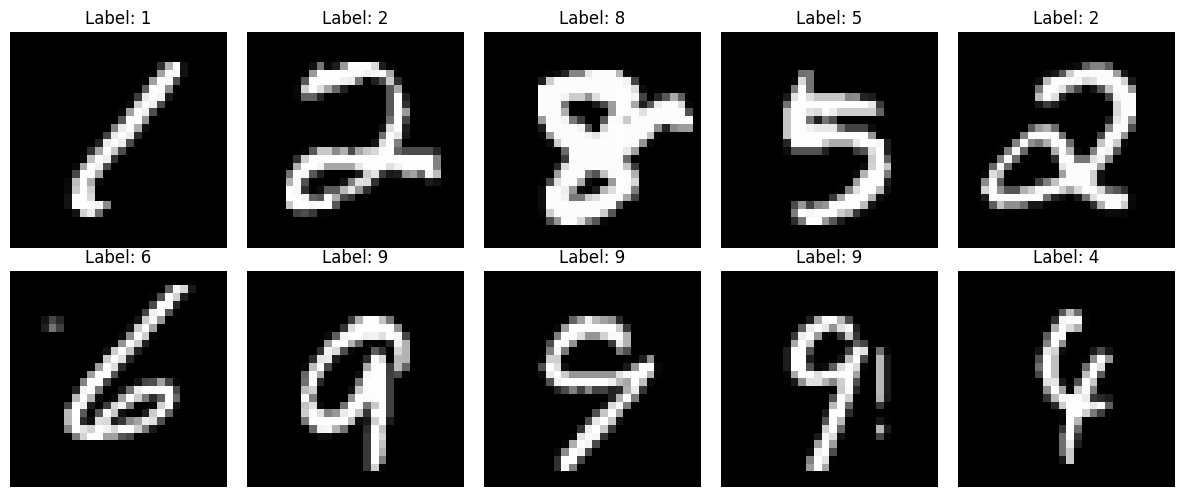

In [5]:
# =========================================================
# 5. DATA EXPLORATION
# =========================================================
class_names = [str(i) for i in range(10)]

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    img = images[i].squeeze().numpy()
    img = img * 0.5 + 0.5  # unnormalize
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Model Architecture

We implement a Convolutional Neural Network (CNN) to extract spatial features from the images and perform classification.

**Architecture overview:**
- Convolutional layers for feature extraction
- Activation functions (ReLU)
- Pooling layers for dimensionality reduction
- Fully connected layers for classification

This architecture is simple yet powerful enough to achieve high accuracy on MNIST.

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=1568, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Training Setup

We define:
- Loss function: CrossEntropyLoss
- Optimizer: SGD (with momentum)
- Number of epochs
- Device (CPU/GPU)

We also ensure reproducibility by setting random seeds.

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
num_epochs = 10

## Model Training

The model is trained over multiple epochs using the training dataset.

During training, we track:
- Training loss
- Training accuracy

In [8]:
# =========================================================
# 8. TRAINING AND EVALUATION FUNCTIONS
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

In [9]:
# =========================================================
# 9. MODEL TRAINING
# =========================================================
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

best_test_acc = 0.0
best_model_state = None

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state = model.state_dict()
    
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}%")
    print(f"Test Loss:  {test_loss:.4f} | Test Accuracy:  {test_acc:.2f}%")
    print("-" * 50)

print(f"Best Test Accuracy: {best_test_acc:.2f}%")

Epoch [1/10]
Train Loss: 1.3631 | Train Accuracy: 61.15%
Test Loss:  0.3719 | Test Accuracy:  89.19%
--------------------------------------------------
Epoch [2/10]
Train Loss: 0.3244 | Train Accuracy: 90.05%
Test Loss:  0.2420 | Test Accuracy:  92.87%
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.2332 | Train Accuracy: 92.90%
Test Loss:  0.1883 | Test Accuracy:  94.32%
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.1798 | Train Accuracy: 94.55%
Test Loss:  0.1448 | Test Accuracy:  95.71%
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.1457 | Train Accuracy: 95.62%
Test Loss:  0.1128 | Test Accuracy:  96.55%
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.1228 | Train Accuracy: 96.32%
Test Loss:  0.1089 | Test Accuracy:  96.64%
--------------------------------------------------
Epoch [7/10]
Train Loss: 0.1062 | Train Accuracy: 96.78%
Test Loss:  0.0969 | Test Accur

In [10]:
# =========================================================
# 10. LOAD BEST MODEL
# =========================================================
model.load_state_dict(best_model_state)

<All keys matched successfully>

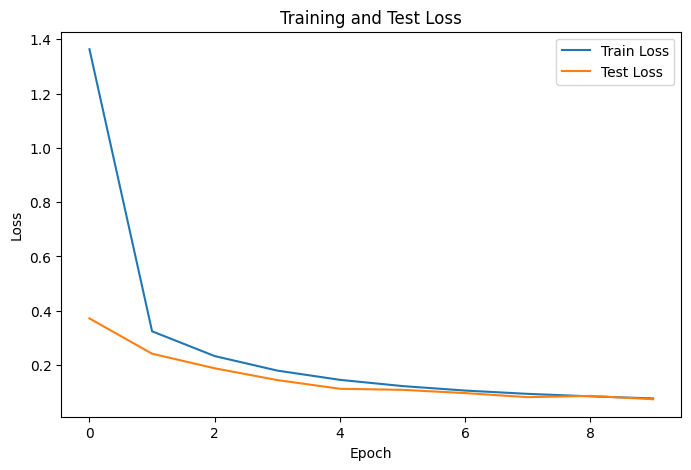

In [11]:
# =========================================================
# 11. TRAINING CURVES
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.show()

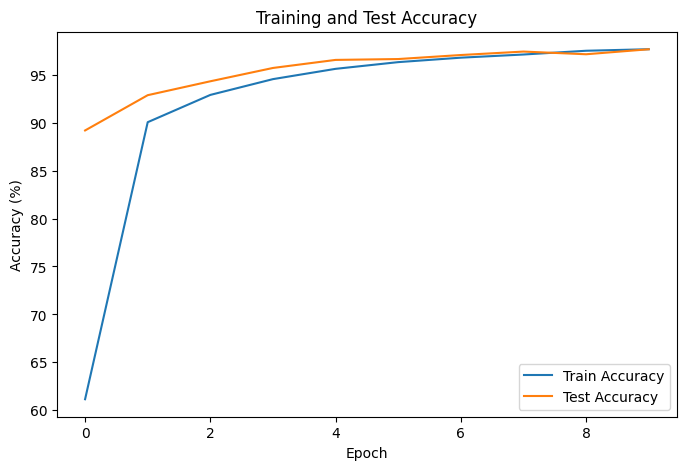

In [12]:
# =========================================================
# 12. ACCURACY CURVES
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Test Accuracy")
plt.legend()
plt.show()

## Model Evaluation

After training, we evaluate the model on the test dataset to measure its generalization performance.

We compute:
- Test accuracy

In [13]:
# =========================================================
# 13. FINAL EVALUATION
# =========================================================
test_loss, test_acc, y_pred, y_true = evaluate(model, test_loader, criterion, device)

print(f"Final Test Accuracy: {test_acc:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

Final Test Accuracy: 97.66%

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      0.98      0.98      1135
           2       0.98      0.98      0.98      1032
           3       0.96      0.99      0.97      1010
           4       0.97      0.99      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.99      0.97      0.98      1028
           8       0.94      0.98      0.96       974
           9       0.99      0.95      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



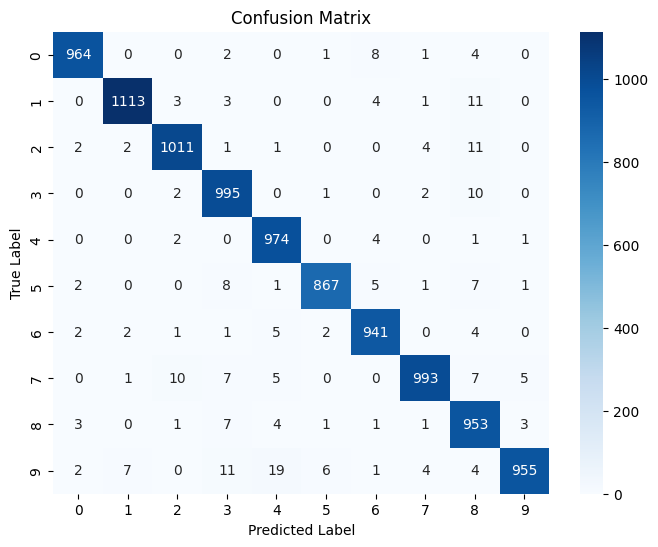

In [14]:
# =========================================================
# 14. CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

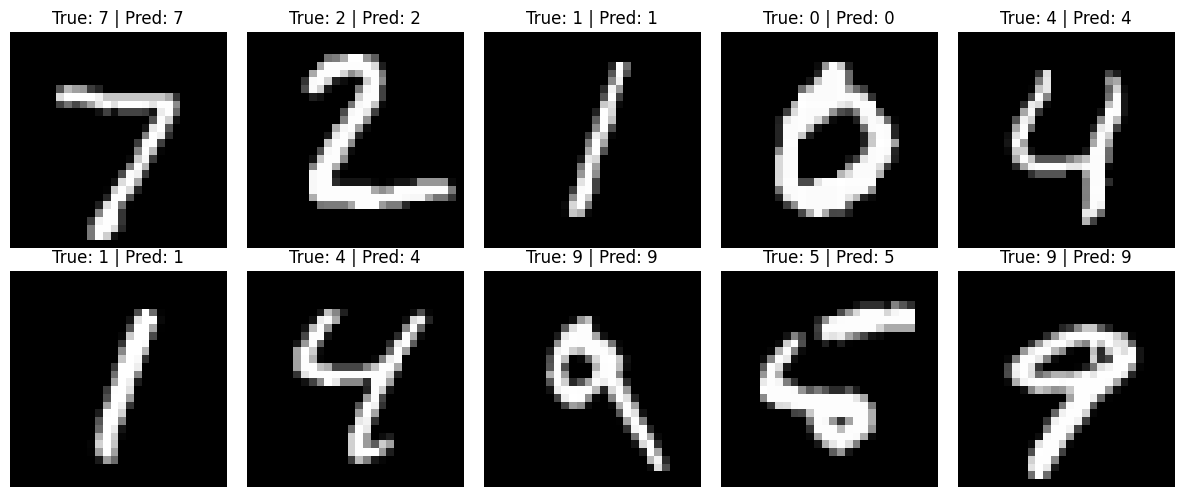

In [15]:
# =========================================================
# 15. SAMPLE PREDICTIONS
# =========================================================
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
predicted = predicted.cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    img = images[i].squeeze().numpy()
    img = img * 0.5 + 0.5  # unnormalize
    
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"True: {labels[i].item()} | Pred: {predicted[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

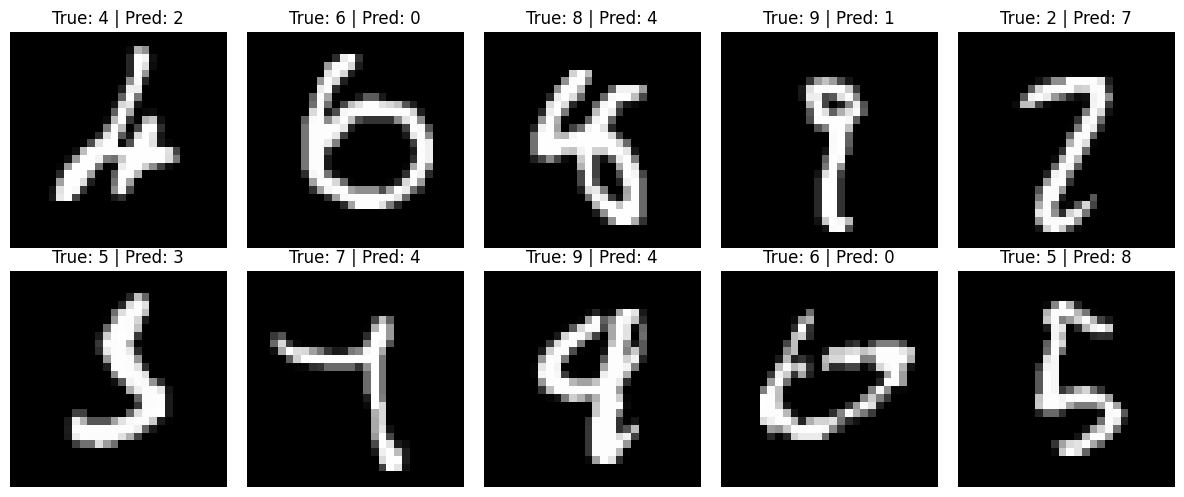

In [16]:
# =========================================================
# 16. SHOW MISCLASSIFIED EXAMPLES
# =========================================================
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        mask = preds != labels
        if mask.any():
            misclassified_images.extend(images[mask].cpu())
            misclassified_labels.extend(labels[mask].cpu())
            misclassified_preds.extend(preds[mask].cpu())

        if len(misclassified_images) >= 10:
            break

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    img = misclassified_images[i].squeeze().numpy()
    img = img * 0.5 + 0.5
    
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"True: {misclassified_labels[i].item()} | Pred: {misclassified_preds[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [17]:
# =========================================================
# 17. SAVE MODEL
# =========================================================
torch.save(model.state_dict(), "mnist_cnn_model.pth")
print("Model saved as mnist_cnn_model.pth")

Model saved as mnist_cnn_model.pth


In [18]:
# =========================================================
# 18. LOAD MODEL
# =========================================================
loaded_model = SimpleCNN().to(device)
loaded_model.load_state_dict(torch.load("mnist_cnn_model.pth", map_location=device))
loaded_model.eval()

print("Model loaded successfully.")

Model loaded successfully.


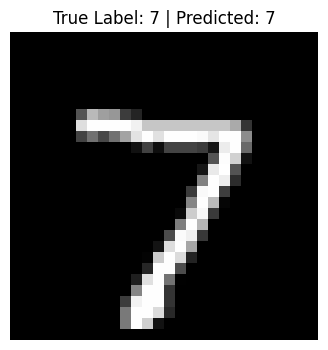

Predicted probabilities:
[[2.7147604e-07 1.9843662e-07 1.5326618e-04 1.2353574e-03 7.2055717e-10
  3.7758855e-07 1.4990892e-12 9.9857664e-01 1.2620769e-06 3.2694214e-05]]


In [19]:
# =========================================================
# 19. SINGLE IMAGE INFERENCE FROM TEST SET
# =========================================================
def predict_single_image(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
    return predicted_class, probabilities.cpu().numpy()

sample_image, sample_label = test_dataset[0]
pred_class, probs = predict_single_image(loaded_model, sample_image, device)

img = sample_image.squeeze().numpy()
img = img * 0.5 + 0.5

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.title(f"True Label: {sample_label} | Predicted: {pred_class}")
plt.axis("off")
plt.show()

print("Predicted probabilities:")
print(probs)

## Results and Analysis

We analyze the model's performance and discuss:
- Accuracy achieved
- Strengths of the model
- Potential improvements

## Visualization

To better understand model performance, we can visualize:
- Sample predictions
- Correct vs incorrect classifications
- Confusion matrix (optional)

## Future Improvements

Possible ways to improve this model:
- Use more advanced architectures
- Apply data augmentation
- Tune hyperparameters
- Try different optimizers (Adam, RMSprop)
- Add regularization techniques (Dropout, BatchNorm)

## Conclusion

In this notebook, we successfully built and trained a CNN to classify handwritten digits using the MNIST dataset.

This project demonstrates the fundamental workflow of a deep learning pipeline:
- Data preprocessing
- Model design
- Training
- Evaluation

It serves as a strong baseline for more advanced computer vision tasks.

## References

- MNIST Dataset: http://yann.lecun.com/exdb/mnist/
- PyTorch Documentation: https://pytorch.org/docs/